# Explainable AI for cyclic temporal data

We build a small, interpretable temporal classification example. The data contain only one binary variable, `active`, whose probability follows a repeating cycle. We then ask a transparent model to explain why the variable is predicted as active or inactive at particular times.

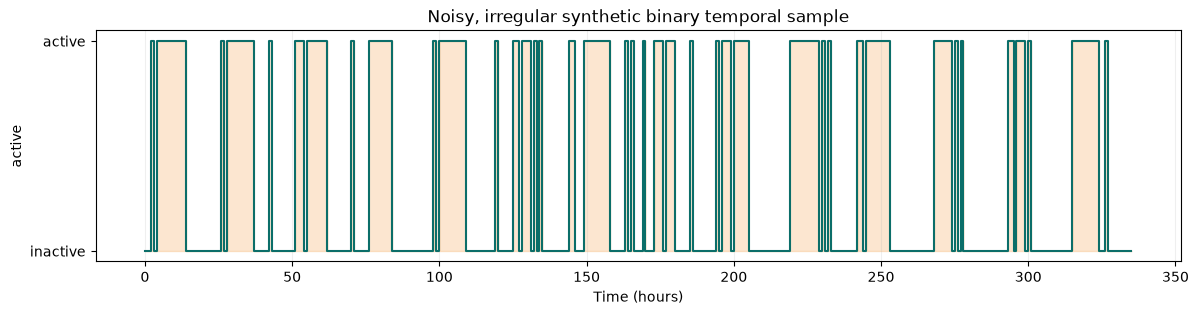

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

rng = np.random.default_rng(7)
n_samples = 24 * 14
hours = np.arange(n_samples)
period = 24
phase = 2 * np.pi * (hours % period) / period
cycle_number = hours // period

# Vary phase, amplitude, and threshold slightly from day to day.
phase_shift = rng.normal(0, 0.16, size=cycle_number.max() + 1)
amplitude = rng.normal(1.0, 0.10, size=cycle_number.max() + 1)
threshold = rng.normal(0.25, 0.08, size=cycle_number.max() + 1)

activity_score = (
    amplitude[cycle_number]
    * np.sin(phase - 0.45 + phase_shift[cycle_number])
    + 0.22 * rng.normal(size=n_samples)
)

active = (
    activity_score > threshold[cycle_number]
).astype(int)

# Occasionally miss an activation or create an unexpected activation.
missed_activations = (active == 1) & (rng.random(n_samples) < 0.08)
unexpected_activations = (active == 0) & (rng.random(n_samples) < 0.04)
active[missed_activations] = 0
active[unexpected_activations] = 1

fig, ax = plt.subplots(figsize=(14, 3))
ax.step(hours, active, where='post', color='#0b6e69', linewidth=1.5)
ax.fill_between(hours, active, step='post', alpha=0.22, color='#f28e2b')
ax.set(
    title='Noisy, irregular synthetic binary temporal sample',
    xlabel='Time (hours)',
    ylabel='active'
)
ax.set_yticks([0, 1], labels=['inactive', 'active'])
ax.grid(axis='x', alpha=0.2)
plt.show()

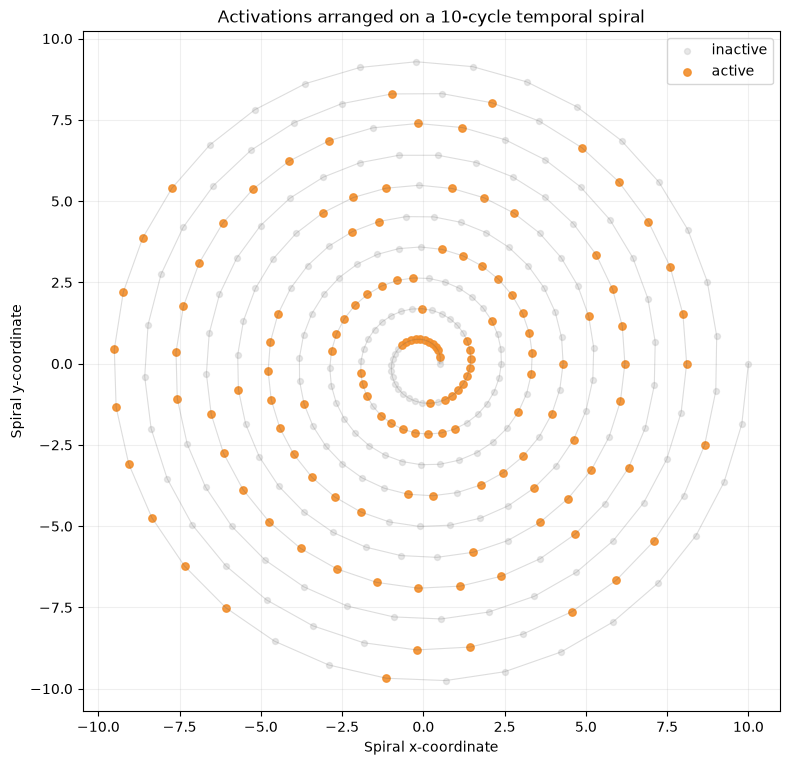

In [37]:
# Arrange the temporal sample along an outward spiral with 10 complete cycles.
n_points = len(active)
theta = np.linspace(0, 10 * 2 * np.pi, n_points)
radius = np.linspace(0.5, 10, n_points)

x_spiral = radius * np.cos(theta)
y_spiral = radius * np.sin(theta)

fig, ax = plt.subplots(figsize=(9, 9))

inactive = active == 0
ax.scatter(
    x_spiral[inactive],
    y_spiral[inactive],
    s=18,
    color='#bdbdbd',
    alpha=0.35,
    label='inactive'
)
ax.scatter(
    x_spiral[active == 1],
    y_spiral[active == 1],
    s=28,
    color='#f28e2b',
    alpha=0.9,
    label='active'
)

ax.plot(x_spiral, y_spiral, color='#555555', alpha=0.2, linewidth=0.8)
ax.set(
    title='Activations arranged on a 10-cycle temporal spiral',
    xlabel='Spiral x-coordinate',
    ylabel='Spiral y-coordinate'
)
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

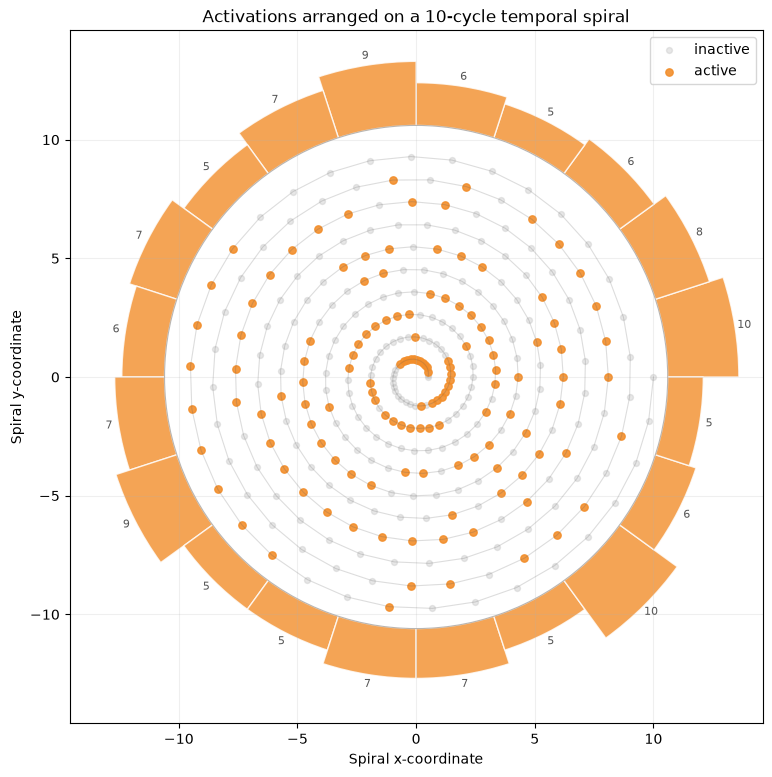

In [38]:
from matplotlib.patches import Wedge

# Arrange the temporal sample along an outward spiral with 10 complete cycles.
n_points = len(active)
theta = np.linspace(0, 10 * 2 * np.pi, n_points)
radius = np.linspace(0.5, 10, n_points)

x_spiral = radius * np.cos(theta)
y_spiral = radius * np.sin(theta)

fig, ax = plt.subplots(figsize=(9, 9))

inactive = active == 0
ax.scatter(
    x_spiral[inactive],
    y_spiral[inactive],
    s=18,
    color='#bdbdbd',
    alpha=0.35,
    label='inactive'
)
ax.scatter(
    x_spiral[active == 1],
    y_spiral[active == 1],
    s=28,
    color='#f28e2b',
    alpha=0.9,
    label='active'
)

ax.plot(x_spiral, y_spiral, color='#555555', alpha=0.2, linewidth=0.8)

# Outer histogram: count active samples in 20 angular (temporal) bins of the cycle.
bin_edges = np.linspace(0, 2 * np.pi, 21)
spiral_phase = np.mod(theta, 2 * np.pi)
bin_counts, _ = np.histogram(spiral_phase[active == 1], bins=bin_edges)

hist_base = radius.max() + 0.6
hist_max_height = 3.0
bar_heights = hist_max_height * bin_counts / bin_counts.max()

for start, end, height, count in zip(bin_edges[:-1], bin_edges[1:], bar_heights, bin_counts):
    ax.add_patch(Wedge(
        (0, 0),
        hist_base + height,
        np.degrees(start),
        np.degrees(end),
        width=height,
        facecolor='#f28e2b',
        edgecolor='white',
        alpha=0.8
    ))
    mid = (start + end) / 2
    label_radius = hist_base + height + 0.4
    ax.text(label_radius * np.cos(mid), label_radius * np.sin(mid), str(count),
            ha='center', va='center', fontsize=8, color='#555555')

ax.add_patch(plt.Circle((0, 0), hist_base, fill=False, color='#555555', alpha=0.4, linewidth=0.8))
plot_limit = hist_base + hist_max_height + 1.0
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)

ax.set(
    title='Activations arranged on a 10-cycle temporal spiral',
    xlabel='Spiral x-coordinate',
    ylabel='Spiral y-coordinate'
)
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.2)
plt.show()


In [39]:
import spirals

print(spirals.__version__)

AttributeError: module 'spirals' has no attribute '__version__'

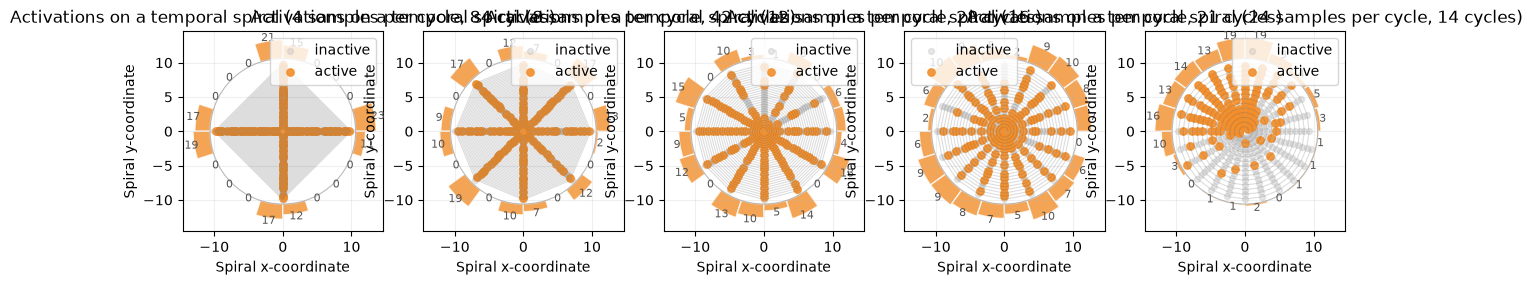

In [23]:
fig, ax_list = plt.subplots(1, 5, figsize=(15, 10))

samples_per_cycle_list = [4, 8, 12, 16, 24]
for i, ax in enumerate(ax_list):
    plot_temporal_spiral(active, n_bins=20, samples_per_cycle=samples_per_cycle_list[i], ax=ax)

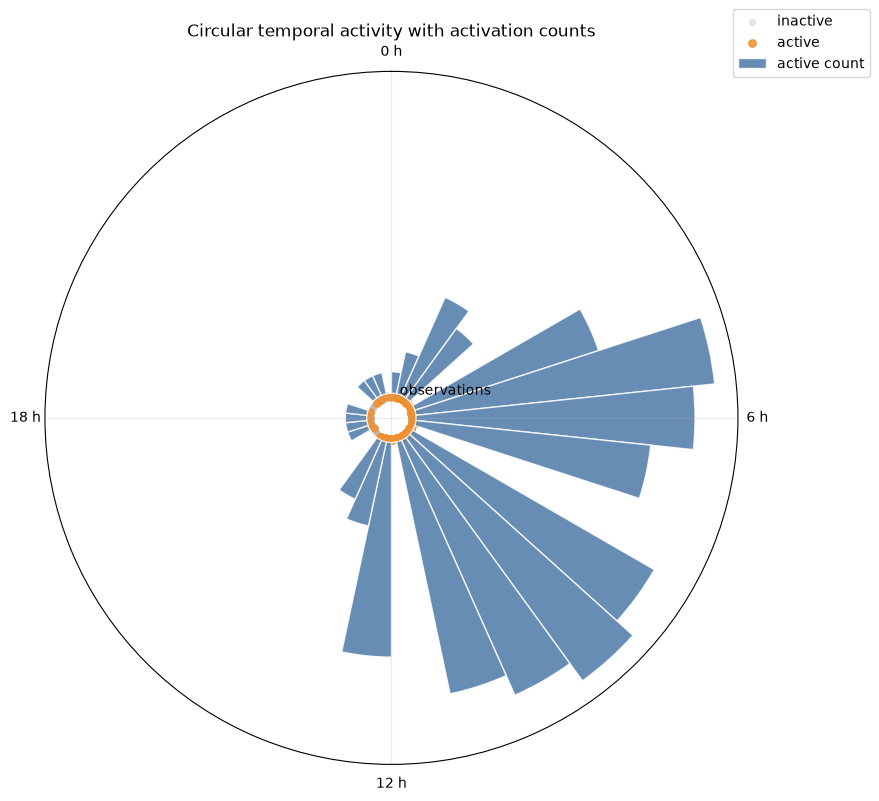

In [12]:
# Circular scatterplot with an outer histogram of activation counts.
bin_edges = np.linspace(0, 2 * np.pi, 31)
activation_counts, _ = np.histogram(
    phase[active == 1],
    bins=bin_edges
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Slight radial jitter makes repeated temporal cycles visible.
scatter_radius = 1 + 0.035 * np.sin(np.arange(n_samples) * 1.7)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})

ax.scatter(
    phase[active == 0],
    scatter_radius[active == 0],
    s=18,
    color='#bdbdbd',
    alpha=0.35,
    label='inactive'
)
ax.scatter(
    phase[active == 1],
    scatter_radius[active == 1],
    s=28,
    color='#f28e2b',
    alpha=0.85,
    label='active'
)

histogram_base = 1.15
ax.bar(
    bin_centers,
    activation_counts,
    width=bin_width,
    bottom=histogram_base,
    color='#4e79a7',
    edgecolor='white',
    alpha=0.85,
    label='active count'
)

ax.set(
    title='Circular temporal activity with activation counts',
    ylim=(0, histogram_base + activation_counts.max() + 1)
)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(np.arange(0, 2 * np.pi, np.pi / 2))
ax.set_xticklabels(['0 h', '6 h', '12 h', '18 h'])
ax.set_yticks([1])
ax.set_yticklabels(['observations'])
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
ax.grid(alpha=0.25)

plt.show()

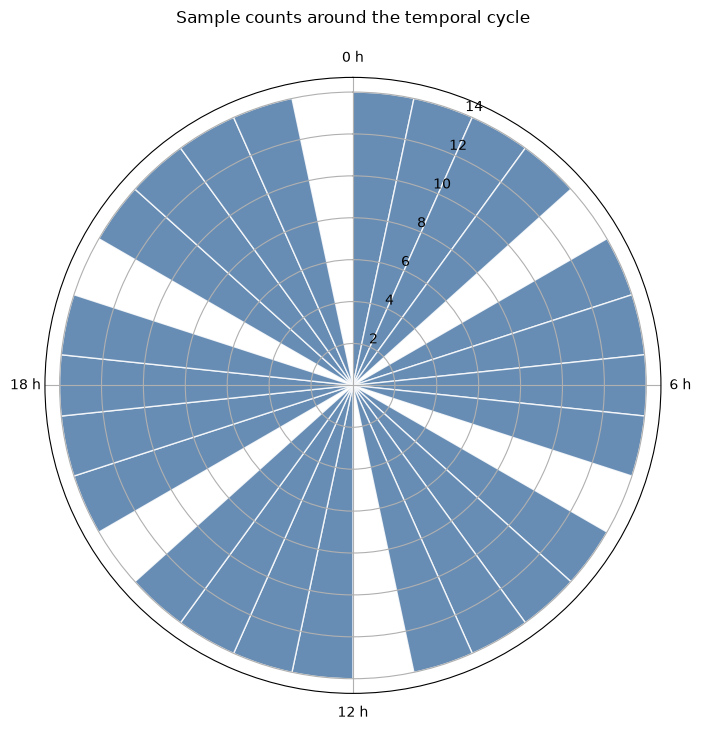

In [3]:
bin_edges = np.linspace(0, 2 * np.pi, 31)
counts, _ = np.histogram(phase, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.bar(
    bin_centers,
    counts,
    width=bin_width,
    align='center',
    color='#4e79a7',
    edgecolor='white',
    alpha=0.85
)

ax.set_title('Sample counts around the temporal cycle', pad=20)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(np.arange(0, 2 * np.pi, np.pi / 2))
ax.set_xticklabels(['0 h', '6 h', '12 h', '18 h'])
plt.show()

## What does the cycle look like?

A cyclic variable has no natural beginning or end. Encoding hour 23 as numerically close to hour 0 requires sine and cosine features rather than a single linear clock value.

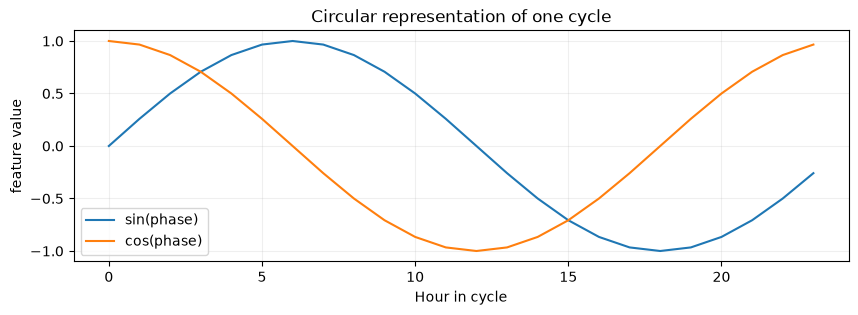

In [2]:
cycle_features = np.column_stack([np.sin(phase), np.cos(phase)])
feature_names = ['sin_phase', 'cos_phase']

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hours[:period], cycle_features[:period, 0], label='sin(phase)')
ax.plot(hours[:period], cycle_features[:period, 1], label='cos(phase)')
ax.set(title='Circular representation of one cycle', xlabel='Hour in cycle', ylabel='feature value')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## A transparent temporal model

We use the first 10 days for training and the remaining 4 days for testing. The model sees the circular phase and the previous hour's state. Its linear coefficients provide a global explanation, while each feature's signed contribution provides a local explanation for one prediction.

test accuracy: 0.948
              precision    recall  f1-score   support

    inactive       0.92      1.00      0.96        55
      active       1.00      0.88      0.94        41

    accuracy                           0.95        96
   macro avg       0.96      0.94      0.95        96
weighted avg       0.95      0.95      0.95        96



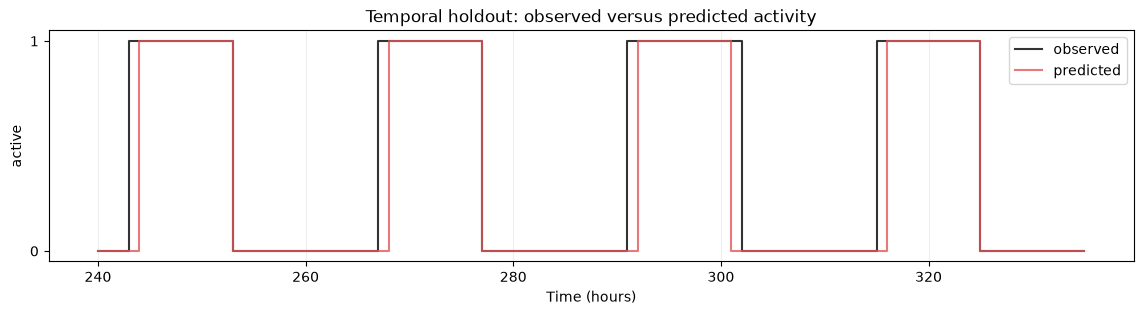

In [3]:
lag_one = np.r_[active[0], active[:-1]]
X = np.column_stack([cycle_features, lag_one])
feature_names = ['sin_phase', 'cos_phase', 'previous_active']
split = 24 * 10
model = LogisticRegression(C=10, solver='lbfgs', random_state=7)
model.fit(X[:split], active[:split])

test_predictions = model.predict(X[split:])
print(f'test accuracy: {accuracy_score(active[split:], test_predictions):.3f}')
print(classification_report(active[split:], test_predictions, target_names=['inactive', 'active']))

fig, ax = plt.subplots(figsize=(14, 3))
ax.step(hours[split:], active[split:], where='post', label='observed', color='#333333')
ax.step(hours[split:], test_predictions, where='post', label='predicted', color='#e15759', alpha=0.8)
ax.set(title='Temporal holdout: observed versus predicted activity', xlabel='Time (hours)', ylabel='active')
ax.set_yticks([0, 1])
ax.legend()
ax.grid(axis='x', alpha=0.2)
plt.show()

       sin_phase: +8.749
       cos_phase: -3.586
 previous_active: +1.923


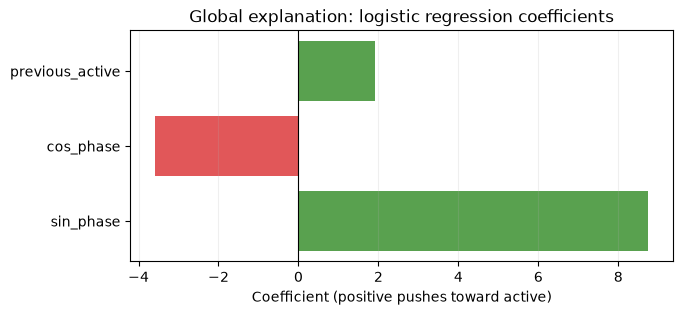

In [4]:
coefficients = model.coef_[0]
for name, coefficient in zip(feature_names, coefficients):
    print(f'{name:>16}: {coefficient:+.3f}')

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#59a14f' if value >= 0 else '#e15759' for value in coefficients]
ax.barh(feature_names, coefficients, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Global explanation: logistic regression coefficients', xlabel='Coefficient (positive pushes toward active)')
ax.grid(axis='x', alpha=0.2)
plt.show()

## Local explanations

For logistic regression, the contribution of feature $j$ to the log-odds is $x_j \beta_j$. The intercept plus all contributions gives the model's log-odds. This is a useful explanation because it preserves both direction and magnitude.

Intercept: -3.723

time=  9, observed=1, predicted_probability=0.999
         sin_phase: +6.187
         cos_phase: +2.536
   previous_active: +1.923

time= 12, observed=1, predicted_probability=0.856
         sin_phase: +0.000
         cos_phase: +3.586
   previous_active: +1.923

time= 17, observed=0, predicted_probability=0.000
         sin_phase: -8.451
         cos_phase: +0.928
   previous_active: +0.000

time= 23, observed=0, predicted_probability=0.000
         sin_phase: -2.264
         cos_phase: -3.464
   previous_active: +0.000

time= 33, observed=1, predicted_probability=0.999
         sin_phase: +6.187
         cos_phase: +2.536
   previous_active: +1.923

time= 41, observed=0, predicted_probability=0.000
         sin_phase: -8.451
         cos_phase: +0.928
   previous_active: +0.000


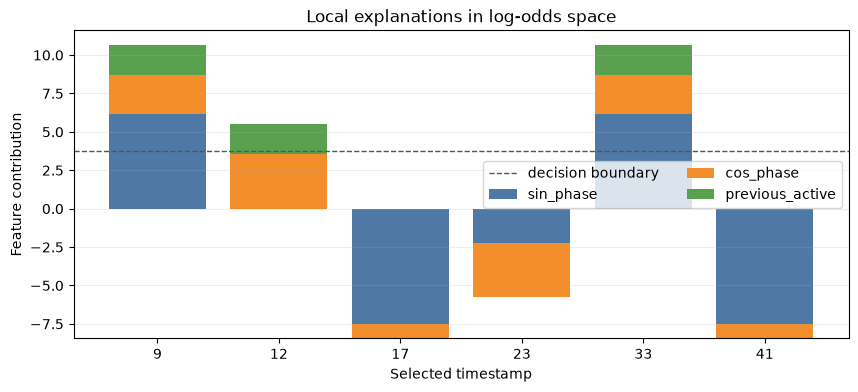

In [5]:
selected_times = np.array([9, 12, 17, 23, 24 + 9, 24 + 17])
local_X = X[selected_times]
contributions = local_X * coefficients
log_odds = model.intercept_[0] + contributions.sum(axis=1)
probabilities = 1 / (1 + np.exp(-log_odds))

print(f'Intercept: {model.intercept_[0]:+.3f}')
for row, time in enumerate(selected_times):
    print(f'\ntime={time:3d}, observed={active[time]}, predicted_probability={probabilities[row]:.3f}')
    for name, value in zip(feature_names, contributions[row]):
        print(f'  {name:>16}: {value:+.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
positions = np.arange(len(selected_times))
bottom = np.zeros(len(selected_times))
colors = ['#4e79a7', '#f28e2b', '#59a14f']
for column, (name, color) in enumerate(zip(feature_names, colors)):
    ax.bar(positions, contributions[:, column], bottom=bottom, label=name, color=color)
    bottom += contributions[:, column]
ax.axhline(-model.intercept_[0], color='#555555', linestyle='--', linewidth=1, label='decision boundary')
ax.set_xticks(positions, labels=[str(time) for time in selected_times])
ax.set(title='Local explanations in log-odds space', xlabel='Selected timestamp', ylabel='Feature contribution')
ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.2)
plt.show()

## Takeaways and limitations

- Sine and cosine preserve the wraparound structure of time, so the explanation can distinguish phase without treating midnight as far from the next midnight.
- Coefficients explain the model globally; $x_j\beta_j$ explains an individual timestamp locally.
- The previous state is informative because activity tends to persist across adjacent hours.
- This is a controlled demonstration, not causal evidence. The signal is synthetic, the cycle is fixed, and the lag feature uses the observed previous state. Real applications should test drift, missing observations, multiple cycles, and whether explanations remain stable out of sample.